# Tutorial

We start importing several classes from the `exogaia` package.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.models import BinaryModel
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.priors import NormalPrior, UniformPrior
from exogaia.results import FitResults
from exogaia.sampler import MCMCSampler, NestedSampler

Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
exogaia

Version: 0.0.2.dev0


In [3]:
source_id = 3009908378049913216  # AF Lep

In [4]:
primary_mass = (1.2, 0.1)  # (Msun)
mass_1 = primary_mass[0]  # (Msun)
mass_2 = 0.01  # (Msun)

In [5]:
sma, ecc, inc, aop, pan, tau = 3., 0.3, np.radians(45.0), np.radians(60.0), np.radians(90.0), 0.5

In [6]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR4')


----------------
Epoch astrometry
----------------

Gaia release: DR4
Reference epoch: 2017.5

Primary mass (Msun): 1.20 +/- 0.10


In [7]:
params = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 3009908378049913216

INFO: Query finished. [astroquery.utils.tap.core]

RA: 81.770 deg +/- 0.012 mas
Dec: -11.901 deg +/- 0.010 mas
Parallax: 37.254 +/- 0.019 mas
Proper motion in RA: 16.915 +/- 0.018 mas/yr
Proper motion in Dec: -49.318 +/- 0.016 mas/yr
G-band magnitude: 6.210


In [8]:
model_param = epoch_astrom.simulate_data(mass_1=mass_1, mass_2=mass_2,
                                         sma=sma, ecc=ecc, inc=inc, aop=aop, pan=pan, tau=tau,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=None, dec=None, parallax=None, pmra=None, pmdec=None, phot_g_mean_mag=None)


-------------
Simulate data
-------------

AL scan uncertainty (per CCD) = 140.25 uas
AL scan uncertainty (per transit) = 49.58 uas

Stellar parameters:
   - RA (deg) = 81.77
   - Dec (deg) = -11.90
   - Parallax (mas) = 37.25
   - Proper motion in RA (mas/yr) = 16.92
   - Proper motion in Dec (mas/yr) = -49.32
   - G-band magnitude = 6.21

Orbit parameters:
   - Primary mass (Msun) = 1.20
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50


In [9]:
bin_model = BinaryModel(epoch_astrometry=epoch_astrom)

In [10]:
model = bin_model.calc_model(model_param=model_param)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 81.77
   - Dec (deg) = -11.90
   - Parallax (mas) = 37.25
   - Proper motion in RA (mas/yr) = 16.92
   - Proper motion in Dec (mas/yr) = -49.32

Orbit parameters:
   - Primary mass (Msun) = 1.20
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50


In [11]:
res = bin_model.calc_residuals(model_param=model_param)


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 81.77
   - Dec (deg) = -11.90
   - Parallax (mas) = 37.25
   - Proper motion in RA (mas/yr) = 16.92
   - Proper motion in Dec (mas/yr) = -49.32

Orbit parameters:
   - Primary mass (Msun) = 1.20
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.16
RUWE = 1.08



----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 81.77
   - Dec (deg) = -11.90
   - Parallax (mas) = 37.25
   - Proper motion in RA (mas/yr) = 16.92
   - Proper motion in Dec (mas/yr) = -49.32

Orbit parameters:
   - Primary mass (Msun) = 1.20
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 3.00
   - Eccentricity = 0.30
   - Inclination (deg) = 45.00
   - Argument of periastron (deg) = 60.00
   - PA of ascending node (deg) = 90.00
   - Relative time of periastron = 0.50

-------------------
Calculate residuals
-------------------

Reduced chi^2 = 1.16
RUWE = 1.08

----------
Plot orbit
----------



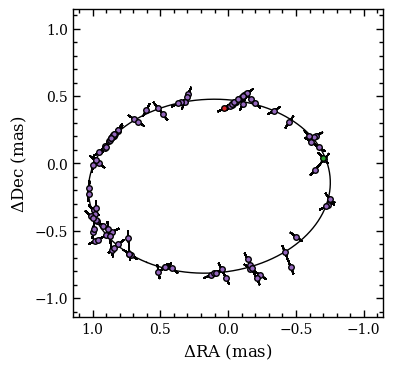

In [12]:
fig = bin_model.plot_orbit(model_param=model_param, plot_file=None)

In [13]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 79.957
RUWE = 8.942
Inflation factor = 8.971

Best-fit parameters:
   - RA (deg) = 81.782 +/- 0.067
   - Dec (deg) = -12.202 +/- 0.065
   - Parallax (mas) = 37.110 +/- 0.101
   - mu in RA (mas/yr) = 16.644 +/- 0.042
   - mu in Dec (mas/yr) = -49.450 +/- 0.047


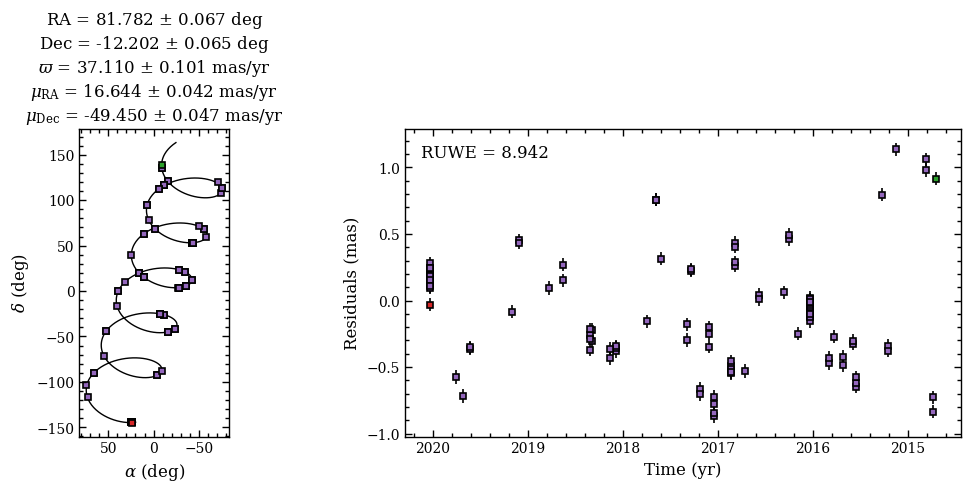

In [14]:
results = leastsq.singl_5param(plot_residuals='res_5param.png')


--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 31.573
RUWE = 5.619
Inflation factor = 5.638

Best-fit parameters:
   - RA (deg) = 82.408 +/- 0.066
   - Dec (mas) = -12.479 +/- 0.056
   - Parallax (mas) = 37.276 +/- 0.066
   - mu in RA (mas/yr) = 16.702 +/- 0.031
   - mu in Dec (mas/yr) = -49.595 +/- 0.035
   - dmu/dt in RA (mas/yr^2) = -0.424 +/- 0.041
   - dmu/dt in Dec (mas/yr^2) = 0.099 +/- 0.043


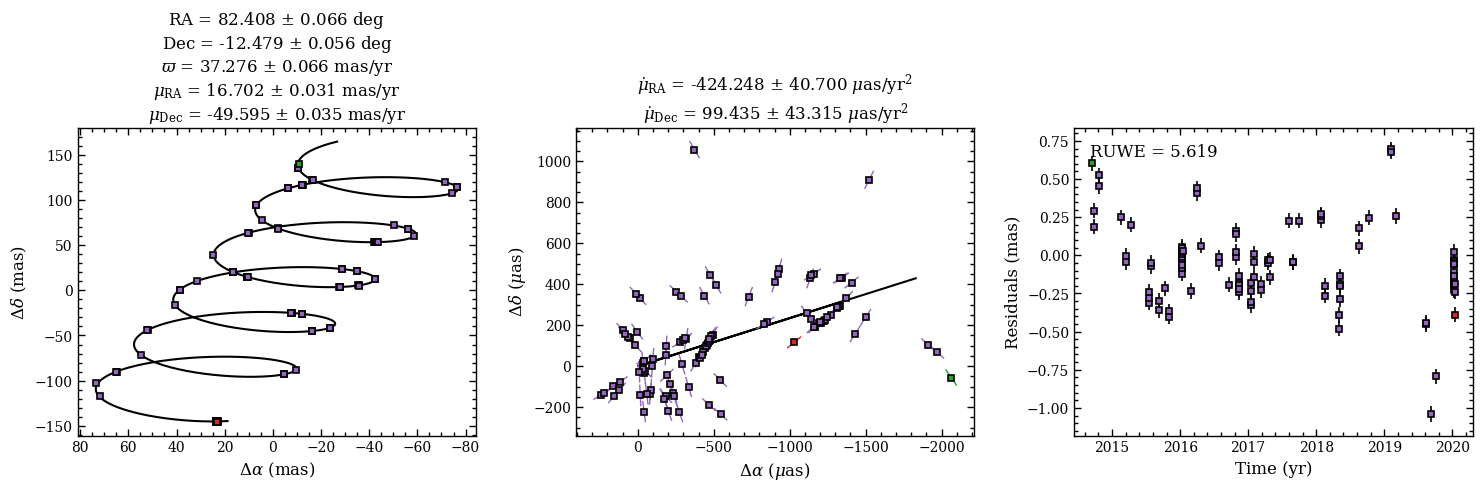

In [15]:
results = leastsq.accel_7param(plot_residuals='res_7param.png')


--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 9.156
RUWE = 3.026
Inflation factor = 3.036

Best-fit parameters:
   - RA (deg) = 82.256 +/- 0.038
   - Dec (deg) = -12.563 +/- 0.033
   - Parallax (mas) = 37.284 +/- 0.035
   - mu in RA (mas/yr) = 16.224 +/- 0.039
   - mu in Dec (mas/yr) = -49.772 +/- 0.034
   - dmu/dt in RA (mas/yr^2) = -0.230 +/- 0.026
   - dmu/dt in Dec (mas/yr^2) = 0.356 +/- 0.030
   - d^2mu/d^2t in RA (mas/yr^3) = 0.720 +/- 0.049
   - d^2mu/d^2t in Dec (mas/yr^3) = 0.468 +/- 0.050


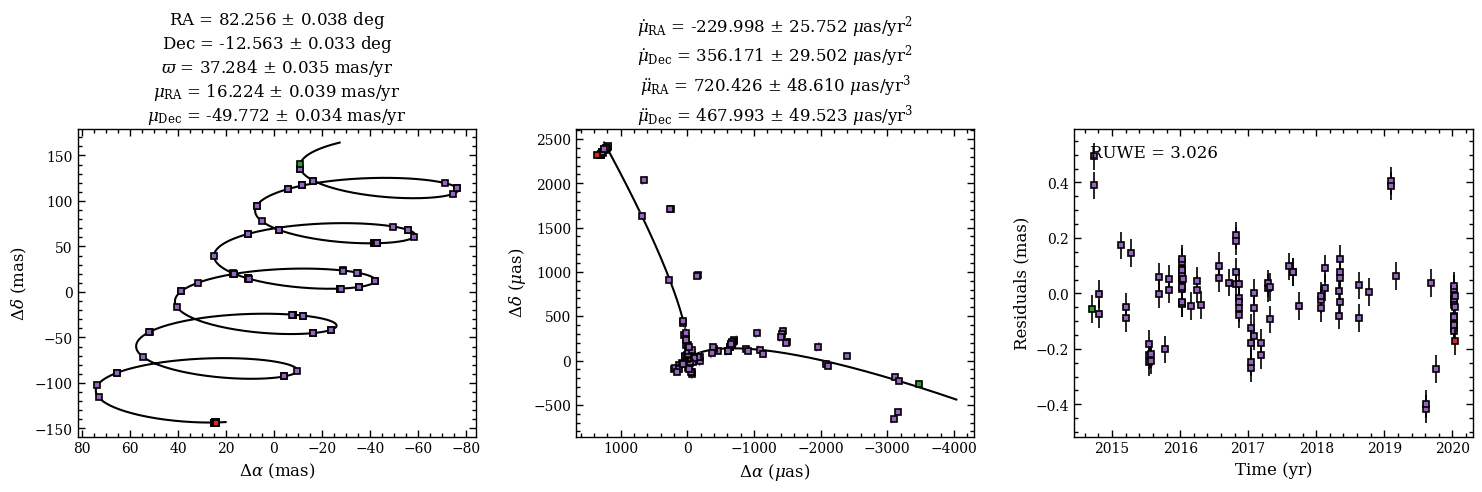

In [16]:
results = leastsq.accel_9param(plot_residuals='res_9param.png')


---------------------
Orbit (12-parameters)
---------------------



  0%|          | 0/125000 [00:00<?, ?it/s]


Best-fit parameters (RUWE = 1.549):
   - RA (deg) = 81.917 +/- 0.014
   - Dec (deg) = -12.101 +/- 0.015
   - Parallax (mas) = 37.267 +/- 0.018
   - mu in RA (mas/yr) = 17.053 +/- 0.013
   - mu in Dec (mas/yr) = -49.270 +/- 0.016
   - Thiele-Innes B = 0.031 +/- 0.023
   - Thiele-Innes G = -1.031 +/- 0.025
   - Thiele-Innes A = -0.668 +/- 0.024
   - Thiele-Innes F = -0.099 +/- 0.023
   - Semi-major axis (au) = 3.286
   - Eccentricity = 0.000
   - Relative time of periastron = 0.07


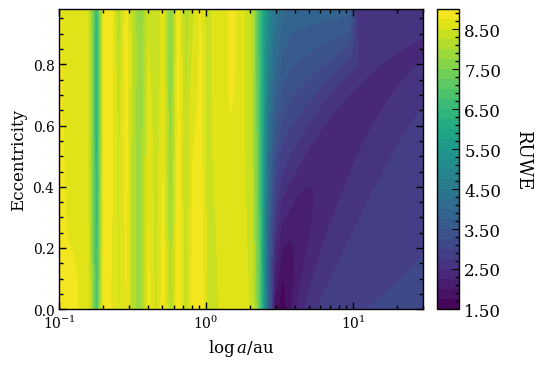

In [17]:
fig = leastsq.orbit_grid(plot_grid='ruwe_orbit.png')

In [18]:
# sampler = NestedSampler(epoch_astrometry=epoch_astrom)
sampler = MCMCSampler(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5-parameters)
--------------------------

Reduced chi^2 = 79.957
RUWE = 8.942
Inflation factor = 8.971

Best-fit parameters:
   - RA (deg) = 81.782 +/- 0.067
   - Dec (deg) = -12.202 +/- 0.065
   - Parallax (mas) = 37.110 +/- 0.101
   - mu in RA (mas/yr) = 16.644 +/- 0.042
   - mu in Dec (mas/yr) = -49.450 +/- 0.047

--------------------------
Binary star (7-parameters)
--------------------------

Reduced chi^2 = 31.573
RUWE = 5.619
Inflation factor = 5.638

Best-fit parameters:
   - RA (deg) = 82.408 +/- 0.066
   - Dec (mas) = -12.479 +/- 0.056
   - Parallax (mas) = 37.276 +/- 0.066
   - mu in RA (mas/yr) = 16.702 +/- 0.031
   - mu in Dec (mas/yr) = -49.595 +/- 0.035
   - dmu/dt in RA (mas/yr^2) = -0.424 +/- 0.041
   - dmu/dt in Dec (mas/yr^2) = 0.099 +/- 0.043

--------------------------
Binary star (9-parameters)
--------------------------

Reduced chi^2 = 9.156
RUWE = 3.026
Inflation factor = 3.036

Best-fit parameters:
   - RA (deg) = 82.25

In [19]:
sampler.run_ptmcmc(
    pickle_file='exogaia.pkl',
    n_temps=10,
    n_walkers=100,
    n_steps=10000,
    n_sweeps=2,
    progress=False,
)

The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 400;
tau: [2338.92125512 2487.7853965  2228.36752552 2423.75732918 2136.06440067
 2036.83023361 2472.00934071 2309.54853756 2423.12649281 2275.75885934
 2415.38446198 2462.75101656 2436.58872014]
The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 400;
tau: [2107.51617338 2290.97099306 2516.4929221  2379.68121158 1894.91700695
 2078.87648771 2297.73159696 2238.69608882 2232.15172712 1966.94011783
 2254.17201564 2289.97426809 2316.38569891]
The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 400;
tau: [2102.39545872 2035.4259316  2149.98358428 1974.23228733 2182.29173409
 2268.53535273 2117.07079074 2077.00075429 2007.10782616 2056.217

In [20]:
results = FitResults(burnin=15000, pickle_file='exogaia.pkl')


-----------
Fit results
-----------

Number of parameters: 13
Samples shape: (10, 20000, 100, 13)

Burnin: 15000
Samples shape: (10, 5000, 100, 13)

Reshaped samples: (5000000, 13)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1


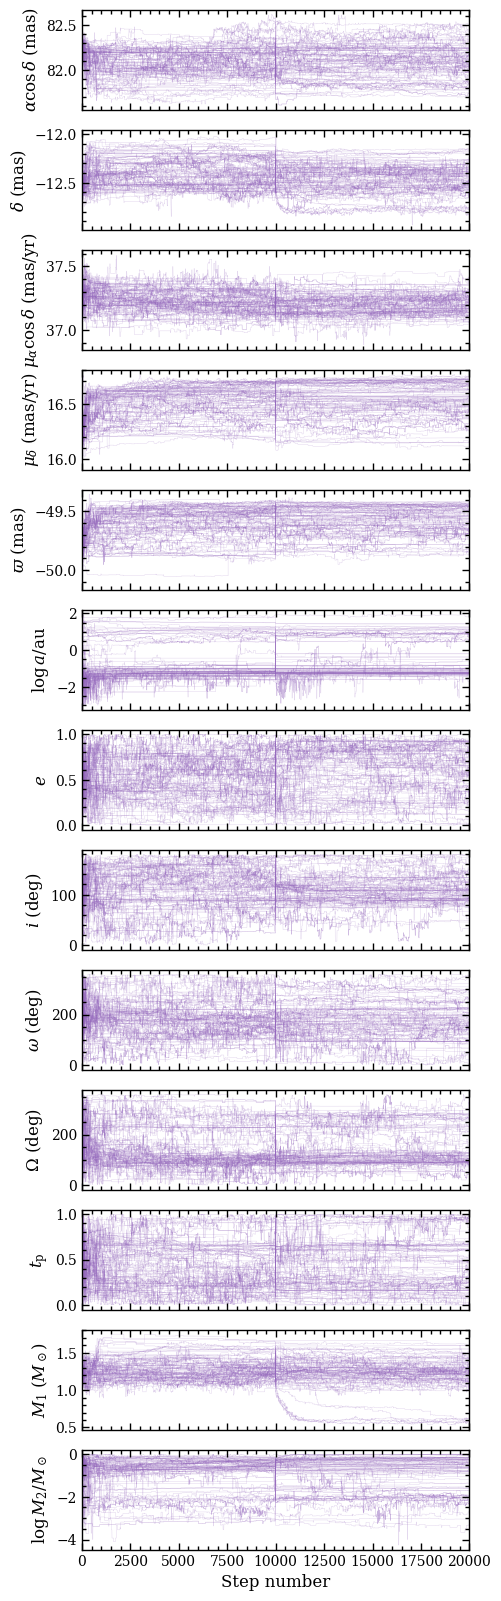

In [21]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file=None)


--------------
Plot posterior
--------------



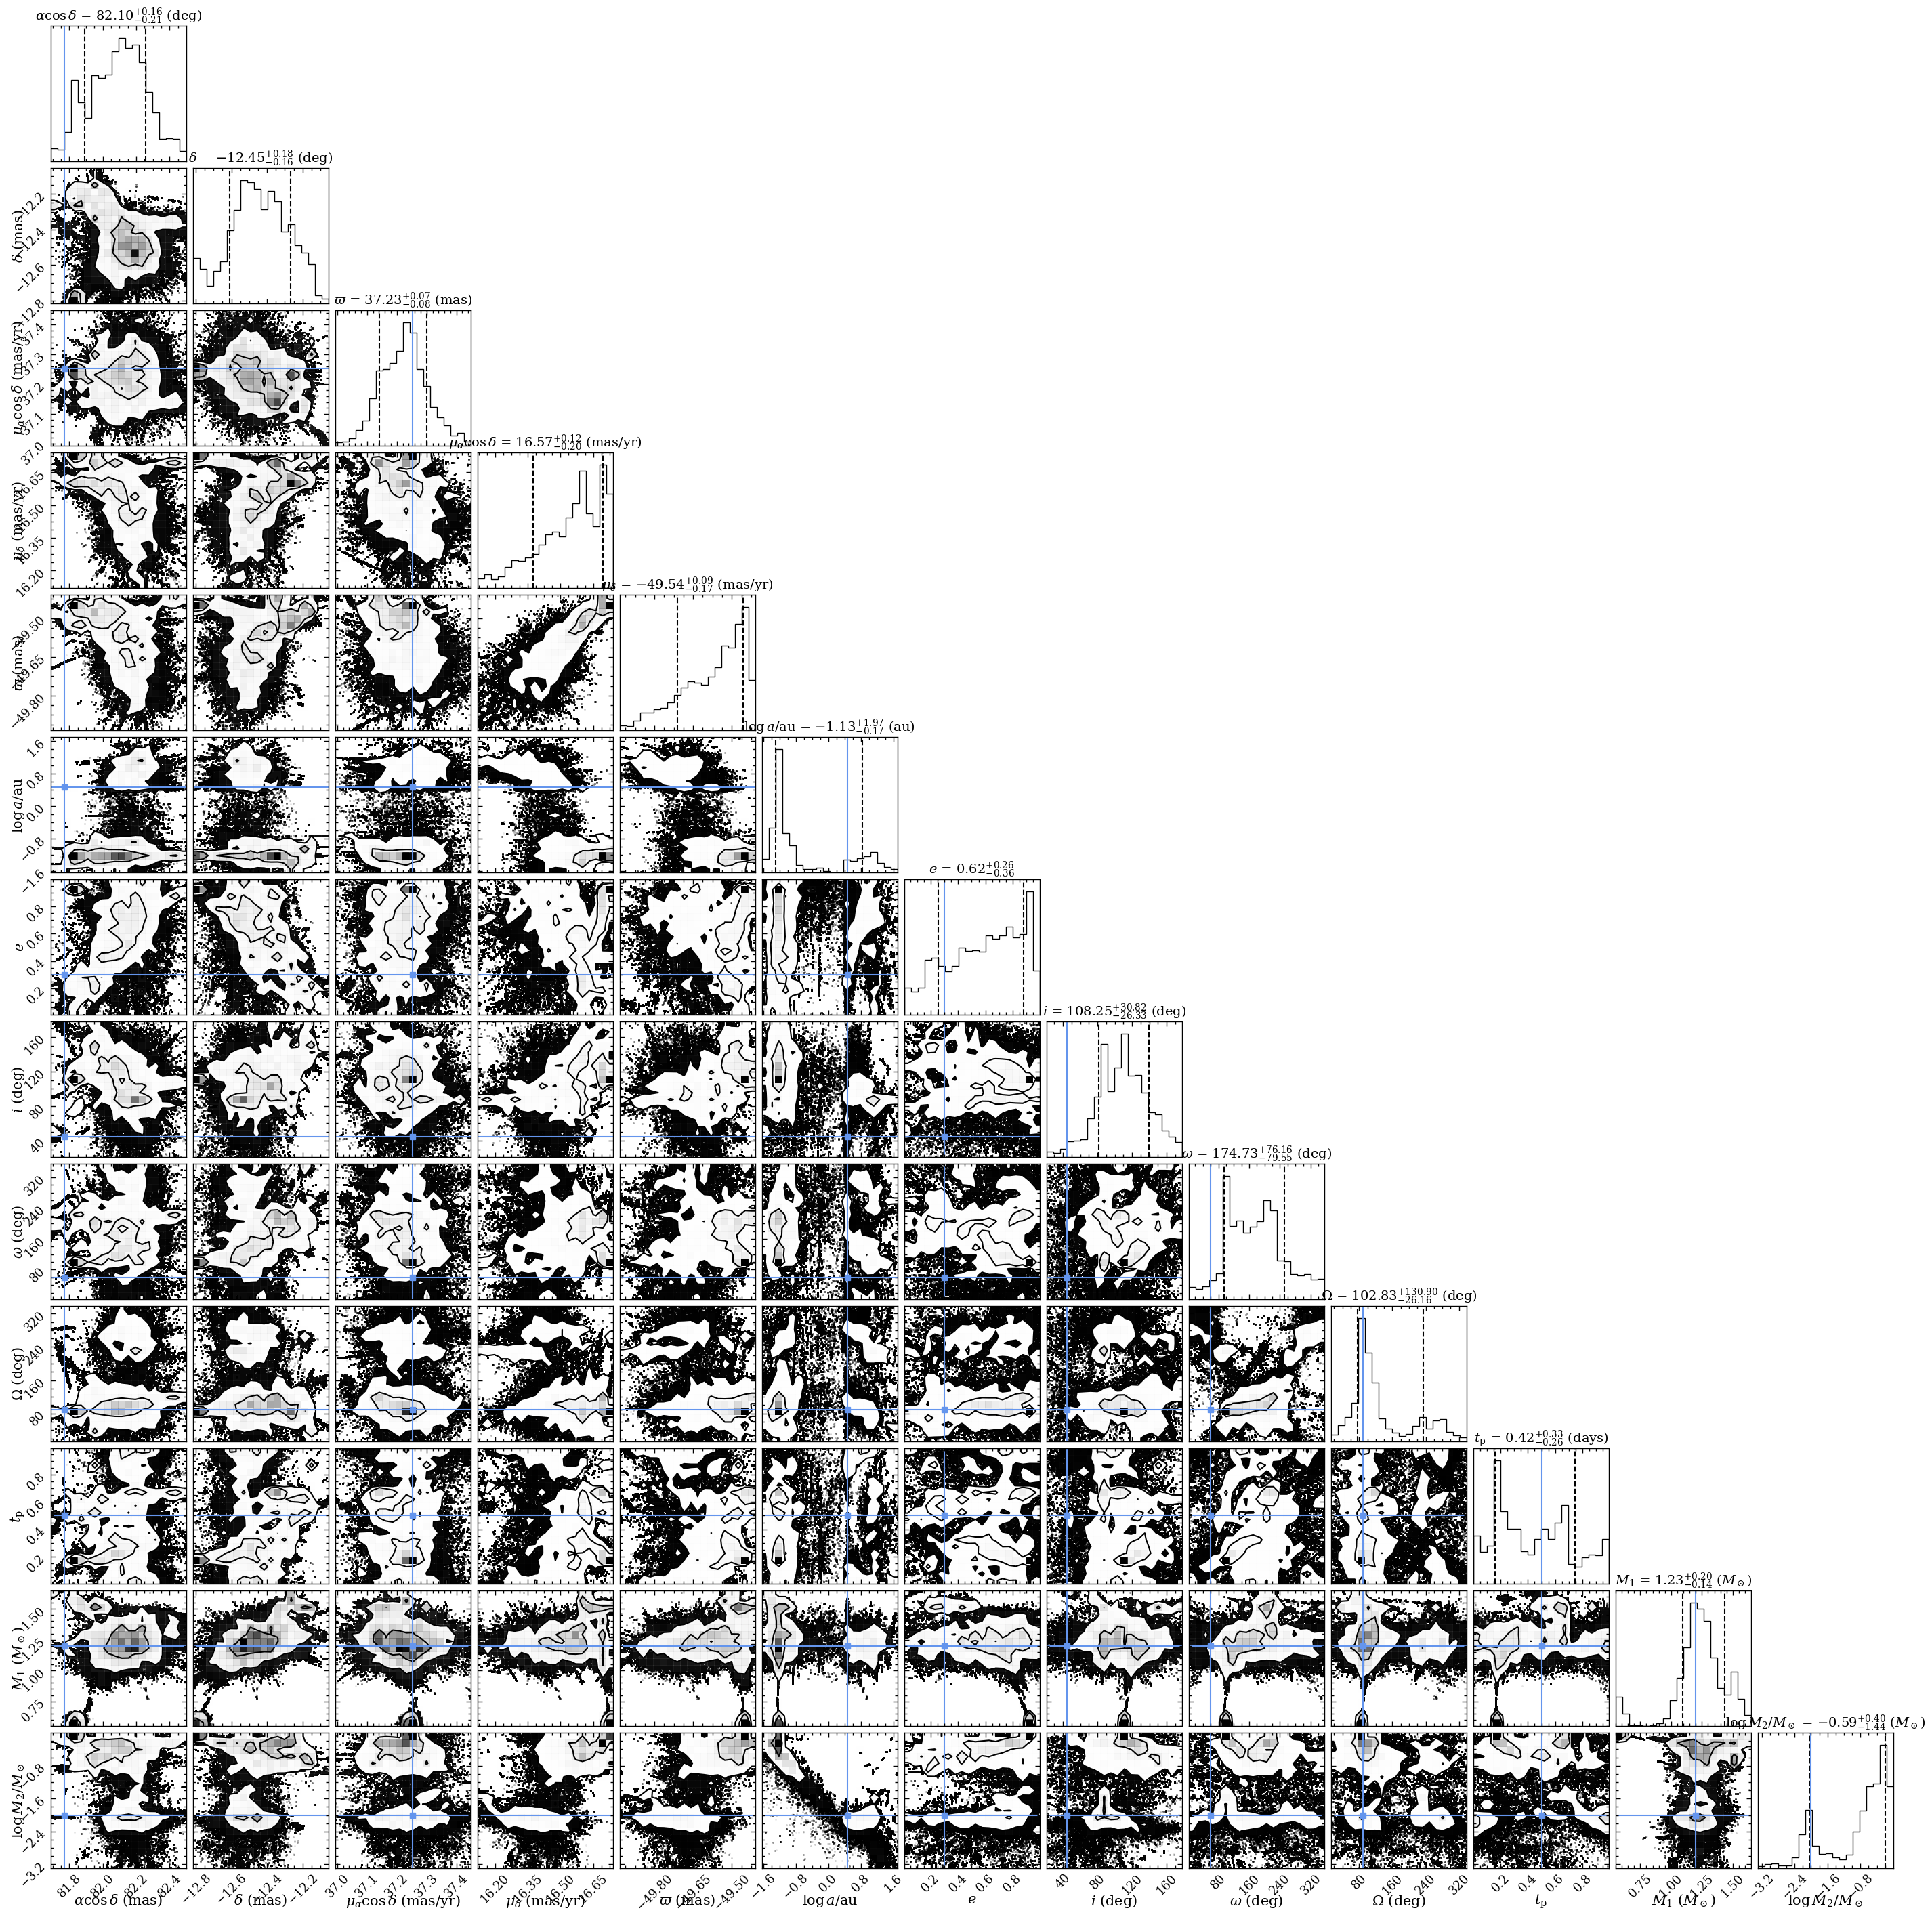

In [22]:
fig = results.plot_posterior(truths=model_param, plot_file=None)


--------------
Plot residuals
--------------


----------------------
Calculate binary model
----------------------

Stellar parameters:
   - RA (deg) = 82.15
   - Dec (deg) = -12.65
   - Parallax (mas) = 37.17
   - Proper motion in RA (mas/yr) = 16.61
   - Proper motion in Dec (mas/yr) = -49.68

Orbit parameters:
   - Primary mass (Msun) = 1.21
   - Secondary mass (Msun) = 0.01
   - Semi-major axis (au) = 7.54
   - Eccentricity = 0.88
   - Inclination (deg) = 104.18
   - Argument of periastron (deg) = 127.51
   - PA of ascending node (deg) = 99.24
   - Relative time of periastron = 0.94


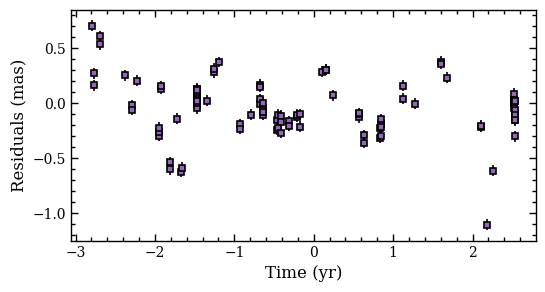

In [23]:
fig = results.plot_residuals(plot_file=None)


----------
Plot orbit
----------



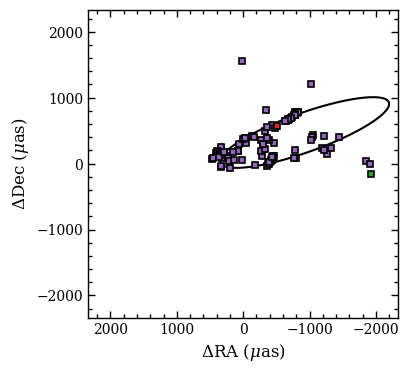

In [24]:
fig = results.plot_orbit(plot_file=None)